# The ChatGPT Generated script from Simon

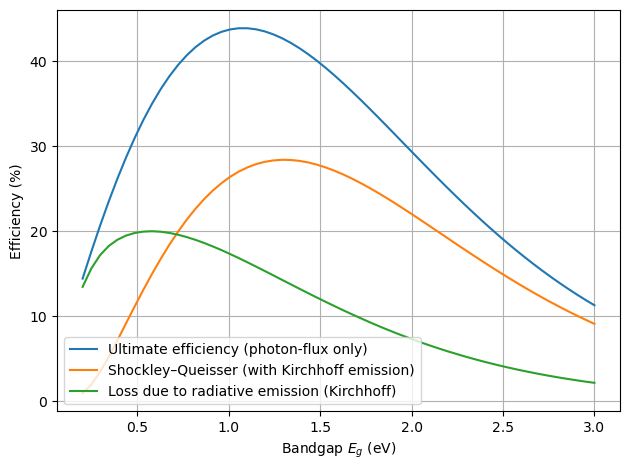

In [1]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

# Physical constants
h  = 6.62607015e-34      # Planck constant (J s)
c  = 2.99792458e8        # Speed of light (m/s)
kB = 1.380649e-23        # Boltzmann constant (J/K)
q  = 1.602176634e-19     # Elementary charge (C)

def phi_bb_E(E, T):
    """
    Spectral photon flux from an ideal black surface into a hemisphere.
    Units: photons / (s m^2 J)
    E in Joules, T in Kelvin.
    """
    # 2π * E^2 / (h^3 c^2 (exp(E/kT) - 1))
    return 2.0 * np.pi * E**2 / (h**3 * c**2 * (np.exp(E / (kB * T)) - 1.0))

def sq_curves(Ts, Tc, Eg_min=0.2, Eg_max=3.0, n_Eg=60):
    """
    Compute:
      - Ultimate (photon-flux-limited) efficiency
      - Shockley–Queisser efficiency
    as a function of bandgap, for given sun and cell temperatures.

    Ts, Tc in Kelvin
    Eg_min, Eg_max in eV
    Returns:
      Eg_eV, eta_ult, eta_sq  (efficiencies as fractions, not %)
    """
    # Bandgap grid (eV -> J)
    Eg_list = np.linspace(Eg_min, Eg_max, n_Eg) * q
    Eg_eV = Eg_list / q

    # Geometric dilution factor for 1-sun (sun at 1 AU)
    # f_geom = Ω_sun / π = (R_sun / d_sun)^2
    R_sun = 6.9634e8       # m
    d_sun = 1.49598e11     # m
    f_geom = (R_sun / d_sun)**2

    # Total incident power from the sun (per m^2 of cell)
    def P_in_integrand(E):
        return E * phi_bb_E(E, Ts) * f_geom
    # Integrate up to 10 eV
    E_max = 10.0 * q
    P_in, _ = integrate.quad(P_in_integrand, 0.0, E_max)

    eta_ult = np.zeros_like(Eg_list)
    eta_sq  = np.zeros_like(Eg_list)

    for i, Eg in enumerate(Eg_list):
        # Photon flux from sun above bandgap
        Phi_in, _ = integrate.quad(
            lambda E: phi_bb_E(E, Ts) * f_geom, Eg, E_max
        )
        J_sc = q * Phi_in

        # Radiative dark current of the cell (Kirchhoff/detailed balance)
        # Cell emits as blackbody at Tc for E > Eg
        J0, _ = integrate.quad(
            lambda E: q * phi_bb_E(E, Tc), Eg, E_max
        )

        # (1) Ultimate efficiency:
        #     Assume every absorbed photon gives energy Eg, no emission loss,
        #     V = Eg/q, FF = 1.
        eta_ult[i] = Phi_in * Eg / P_in

        # (2) Full SQ efficiency: include radiative recombination.
        #     J(V) = J_sc - J0 (exp(qV/kT) - 1)
        V_array = np.linspace(0.0, Eg / q, 200)
        J = J_sc - J0 * (np.exp(q * V_array / (kB * Tc)) - 1.0)
        P = J * V_array
        eta_sq[i] = np.max(P) / P_in

    return Eg_eV, eta_ult, eta_sq

def main():
    # Temperatures
    Ts = 5778.0  # Sun temperature (K)
    Tc = 353   # Cell temperature (K)

    Eg_eV, eta_ult, eta_sq = sq_curves(Ts, Tc)

    plt.figure()
    plt.plot(Eg_eV, 100 * eta_ult, label="Ultimate efficiency (photon-flux only)")
    plt.plot(Eg_eV, 100 * eta_sq,  label="Shockley–Queisser (with Kirchhoff emission)")
    plt.plot(Eg_eV, 100 * (eta_ult - eta_sq),
             label="Loss due to radiative emission (Kirchhoff)")
    plt.xlabel(r"Bandgap $E_g$ (eV)")
    plt.ylabel("Efficiency (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()